In [70]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated, List
from langchain_groq import ChatGroq
import operator
from dotenv import load_dotenv
from pydantic import BaseModel, Field
import os
load_dotenv()  # Load environment variables from .env file

True

In [71]:
model= ChatGroq(
    model="openai/gpt-oss-120b",
    groq_api_key=os.getenv("GROQ_API_KEY")
)


In [72]:
class EssayState(TypedDict):
    essay_text: str
    feedback_language: str
    feedback_analysis: str
    feedback_quality: str
    summary_feedback: str
    individual_scores: Annotated[List[float], operator.add]
    avg_score: float

In [74]:
class ResponseStructure(BaseModel):
    feedback: str = Field(
        ...,
        description="Detailed feedback on the essay's content, structure, clarity, grammar, and argument quality."
    )
    score: float = Field(
        ...,
        ge=0,
        le=10,
        description="Overall essay score from 0 to 10. Decimal scores such as 6.5 are allowed."
    )

In [77]:
Structure_model = model.with_structured_output(ResponseStructure)

In [75]:
graph=StateGraph(EssayState)

In [ ]:
def Language_Feedback_llm(state: EssayState) -> EssayState:
    prompt = f"""
    You are an expert essay evaluator. Please provide detailed feedback on the following essay, focusing on language, grammar, and clarity. 
    Essay: {state['essay_text']}
    """
    response = Structure_model.invoke(prompt)
    return{
        "feedback_language": response.feedback,
        "individual_scores": [response.score]
    }


In [79]:
def Analysis_Feedback_llm(state: EssayState) -> EssayState:
    prompt = f"""
    You are an expert essay evaluator. Please provide detailed feedback on the following essay, focusing on content, structure, and argument quality. 
    Essay: {state['essay_text']}
    """
    response = Structure_model.invoke(prompt)
    return{
        "feedback_analysis": response.feedback,
        "individual_scores": [response.score]
    }

In [80]:
def Quality_Feedback_llm(state: EssayState) -> EssayState:
    prompt = f"""
    You are an expert essay evaluator. Please provide detailed feedback on the following essay, focusing on overall quality, coherence, and persuasiveness. 
    Essay: {state['essay_text']}
    """
    response = Structure_model.invoke(prompt)
    return{
        "feedback_quality": response.feedback,
        "individual_scores": [response.score]
    }

In [81]:
def Summary_Feedback_llm(state: EssayState) -> EssayState:
    avg_score = sum(state['individual_scores']) / len(state['individual_scores']) if state['individual_scores'] else 0
    prompt = f"""
    You are an expert essay evaluator. Please provide a summary of the feedback received on the following essay, including language, analysis, and quality.
    Essay: {state['essay_text']}
    Language Feedback: {state['feedback_language']}
    Analysis Feedback: {state['feedback_analysis']}
    Quality Feedback: {state['feedback_quality']}
    Average Score: {avg_score}
    """
    summary_model = ChatGroq(
        model="openai/gpt-oss-120b",
        groq_api_key=os.getenv("GROQ_API_KEY")
    )
    response = summary_model.invoke(prompt)
    return {
        "summary_feedback": response.content,
        "avg_score": round(avg_score, 2)
    }

In [82]:
# Initialize the graph with the starting state
graph.add_node("Language_Feedback", Language_Feedback_llm)
graph.add_node("Analysis_Feedback", Analysis_Feedback_llm)
graph.add_node("Quality_Feedback", Quality_Feedback_llm)

graph.add_node("Summary_Feedback", Summary_Feedback_llm)


ValueError: Node `Language_Feedback` already present.

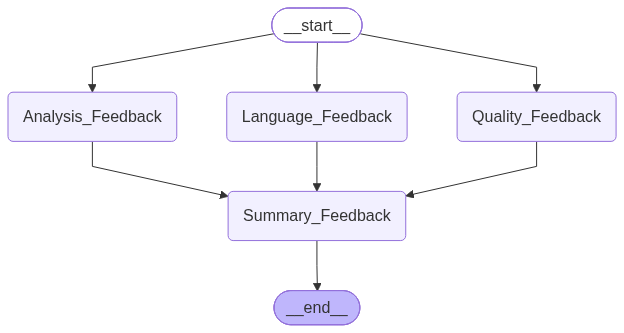

In [84]:
graph.add_edge(START, "Language_Feedback")
graph.add_edge(START, "Analysis_Feedback")
graph.add_edge(START, "Quality_Feedback")
graph.add_edge("Language_Feedback", "Summary_Feedback")
graph.add_edge("Analysis_Feedback", "Summary_Feedback")
graph.add_edge("Quality_Feedback", "Summary_Feedback")
graph.add_edge("Summary_Feedback", END)
graph.compile()

In [83]:
workflow=graph.compile()


ValueError: Graph must have an entrypoint: add at least one edge from START to another node

In [66]:
eassy_text = """ Tyme is the most valuabel thing in the hole world, but many peeple do not reelize it untill it is entirely gone. If you waste your hours on useles things, you will regret it genericly later in life. For exampel, school students often forget to do there homework becuase they are playing video games instead of studing. This lead to bad grades and big disapointment for there parents.In conclution, we must allways try to manage our scedule normaly. If we do not care about clock, success will be imposible to achieve."""

In [78]:
initial_state={
    "essay_text": eassy_text,}
final_state=workflow.invoke(initial_state)
print(f"{final_state['summary_feedback']} and the average score is {final_state['avg_score']}")


BadRequestError: Error code: 400 - {'error': {'message': 'Tool choice is required, but model did not call a tool', 'type': 'invalid_request_error', 'code': 'tool_use_failed', 'failed_generation': '**Summary of Feedback**\n\n---\n\n### 1. Language (Spelling, Grammar & Mechanics)  \n- **Spelling & Word Choice:** 20+ misspellings (e.g., *Tyme → time, valuabel → valuable, hole → whole, peeple → people*). Several incorrect word forms (*genericly, allways, scedule*).  \n- **Punctuation & Capitalization:** Missing commas, periods, and spaces after full‑stops; run‑on sentences (e.g., “parents.In conclution”). Inconsistent capitalization.  \n- **Grammar:** Subject‑verb agreement errors (*lead → leads*), article misuse, pronoun‑antecedent mismatches, and vague adverbs (*genericly*).  \n- **Result:** The language problems severely impede readability and distract from the argument.\n\n### 2. Analysis (Content & Development)  \n- **Main Idea:** Time is the most valuable resource; mis‑managing it le